# RQ3: Hitzewellen in europäischen Großstädten (1980–2025)

**Forschungsfrage:** Wie haben sich Häufigkeit, Intensität und Dauer von Hitzewellen in europäischen Großstädten (≥500.000 Einwohner oder Landeshauptstadt) zwischen 1980 und heute verändert — und welches Land ist am stärksten betroffen?

**Vorgehen:**
1. Städteliste laden
2. Tägliche Höchsttemperaturen laden (1961–2025)
3. Hitzewellen erkennen (DWD-Definition: ≥3 Tage in Folge ungewöhnlich heiß)
4. Europaweiten Trend auswerten
5. Länder vergleichen, am stärksten betroffenes Land bestimmen

Alle Wetter- und Städtedaten liegen bereits lokal im Cache — dieses Notebook ruft beim Ausführen keine externe API neu auf.

Zelle 2 — Städte laden

Alle Städte mit ≥500.000 Einwohnern in 49 europäischen Ländern, ergänzt um jede Landeshauptstadt (auch unter 500.000 Einwohner, z. B. Reykjavik). Das Ergebnis liegt als CSV im Cache.

In [26]:
# Zelle 3
import pandas as pd
import numpy as np

cities_df = pd.read_csv("data/raw/cities_europe.csv")
print(f"{len(cities_df)} Städte in {cities_df['country'].nunique()} Ländern")

101 Städte in 50 Ländern


Zelle 4 — Duplikate ausschließen

Zwei Einträge sind historische Stadtteile Budapests ("Pest" und "Buda"), die GeoNames fälschlich als eigene Städte listet — beide werden ausgeschlossen (Budapest selbst bleibt enthalten).

In [27]:
# Zelle 5
# "Pest" und "Buda" sind Duplikate von Budapest -- werden erst bei der Auswertung übersprungen,
# nicht schon hier aus cities_df entfernt. Grund: cities_df bestimmt die Batch-Aufteilung beim
# Wetterdaten-Fetch (Zelle 11) -- würden wir hier umsortieren, würde das die Batches anders
# zusammensetzen als beim ursprünglichen Lauf, der den Cache gefüllt hat, und der Cache würde
# nicht mehr greifen.
exclude_idx = {27, 75}
print(f"{len(cities_df) - len(exclude_idx)} Städte nach Bereinigung (von {len(cities_df)})")

99 Städte nach Bereinigung (von 101)


Zelle 6 — Verbindung zu Open-Meteo (mit Cache)

Der lokale Cache (`openmeteo_cache.sqlite`) enthält bereits alle benötigten Daten — die folgenden Abfragen werden aus dem Cache beantwortet, nicht live geladen.

In [28]:
# Zelle 7
import openmeteo_requests
import requests_cache
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

cache_session = requests_cache.CachedSession("openmeteo_cache", expire_after=-1)
# Robuste Retry-Einstellungen: kosten nichts, wenn alles aus dem Cache kommt (keine Live-Anfrage,
# keine Wartezeit) -- schützen aber, falls doch mal ein Batch fehlt und live nachgefragt wird.
retry = Retry(total=6, backoff_factor=3, status_forcelist=[429, 500, 502, 503, 504], allowed_methods=["GET"])
cache_session.mount("https://", HTTPAdapter(max_retries=retry))

CLIENT = openmeteo_requests.Client(session=cache_session)

Zelle 8 — Wie eine Hitzewelle definiert wird

Nach der Definition des Deutschen Wetterdienstes (DWD): mindestens 3 Tage in Folge, die sowohl ungewöhnlich heiß **für die jeweilige Stadt** sind (über dem 98. Perzentil vergleichbarer Tage der Referenzperiode 1961–1990) als auch **in absoluten Zahlen** heiß sind (über 28°C). Der feste 28°C-Wert verhindert, dass z. B. ein für Reykjavik ungewöhnlich warmer 12°C-Tag als Hitzewelle zählt.

In [29]:
# Zelle 9
import time

ARCHIVE_URL = "https://archive-api.open-meteo.com/v1/archive"

def fetch_tmax_batch(client, coords, start_date, end_date, batch_size=15, pause=0.1):
    """Tages-Maximaltemperatur für mehrere Städte gleichzeitig laden."""
    dfs = []
    for i in range(0, len(coords), batch_size):
        chunk = coords[i:i + batch_size]
        params = {
            "latitude": [lat for lat, lon in chunk],
            "longitude": [lon for lat, lon in chunk],
            "start_date": start_date, "end_date": end_date,
            "daily": ["temperature_2m_max"],
            "timezone": "Europe/Berlin",
        }
        responses = client.weather_api(ARCHIVE_URL, params=params)
        for response in responses:
            daily = response.Daily()
            tmax = daily.Variables(0).ValuesAsNumpy()
            dates = pd.date_range(
                start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                freq=pd.Timedelta(seconds=daily.Interval()),
                inclusive="left",
            ).tz_localize(None)
            dfs.append(pd.DataFrame({"date": dates, "tmax": tmax}))
        time.sleep(pause)
    return dfs


def fetch_tmax_range(client, coords, start_date, end_date, batch_size=15, year_chunk=5, pause=0.1):
    """Langer Zeitraum -> in Jahresblöcke aufteilen, danach pro Stadt zusammenfügen."""
    start_year, end_year = int(start_date[:4]), int(end_date[:4])
    all_parts = {i: [] for i in range(len(coords))}

    y = start_year
    while y <= end_year:
        y2 = min(y + year_chunk - 1, end_year)
        dfs = fetch_tmax_batch(client, coords, f"{y}-01-01", f"{y2}-12-31", batch_size, pause)
        for i, df in enumerate(dfs):
            all_parts[i].append(df)
        y = y2 + 1

    return [pd.concat(all_parts[i], ignore_index=True).sort_values("date").reset_index(drop=True)
            for i in range(len(coords))]


def compute_doy_thresholds(ref_df, window=15, percentile=98):
    """98. Perzentil pro Kalendertag (±15 Tage), aus der Referenzperiode."""
    doy, tmax = ref_df["doy"].to_numpy(), ref_df["tmax"].to_numpy()
    thresholds = {}
    for d in range(1, 366):
        dist = np.minimum(np.abs(doy - d), 365 - np.abs(doy - d))
        thresholds[d] = np.percentile(tmax[dist <= window], percentile)
    return thresholds


def _summarize(segment, min_days):
    if len(segment) < min_days:
        return None
    return {
        "start": segment["date"].iloc[0].date(), "end": segment["date"].iloc[-1].date(),
        "duration_days": len(segment),
        "max_temp": round(segment["tmax"].max(), 1),
        "avg_temp": round(segment["tmax"].mean(), 1),
    }


def find_dwd_heatwaves(df, thresholds, min_days=3, fixed_threshold=28.0):
    """Zusammenhängende Serien >= min_days Tage über beiden Schwellen."""
    df = df.copy()
    df["doy"] = df["date"].dt.dayofyear.clip(upper=365)
    df["is_hot"] = (df["tmax"] > df["doy"].map(thresholds)) & (df["tmax"] > fixed_threshold)

    heatwaves, start = [], None
    for i, row in df.iterrows():
        if row["is_hot"] and start is None:
            start = i
        elif not row["is_hot"] and start is not None:
            heatwaves.append(_summarize(df.loc[start:i - 1], min_days))
            start = None
    if start is not None:
        heatwaves.append(_summarize(df.loc[start:], min_days))
    return [h for h in heatwaves if h is not None]


def analyze_city_heatwaves(ref_df, analysis_df):
    ref_df = ref_df.copy()
    ref_df["doy"] = ref_df["date"].dt.dayofyear.clip(upper=365)
    return find_dwd_heatwaves(analysis_df, compute_doy_thresholds(ref_df))

Zelle 10 — Referenz- und Analysezeitraum laden

30 Jahre (1961–1990) als Vergleichsbasis, 46 Jahre (1980–2025) als Analysezeitraum, für alle Städte. Beides liegt vollständig im Cache — dieser Schritt braucht deshalb nur Sekunden statt der ursprünglichen ~15 Minuten.

In [30]:
# Zelle 11
# Bewusst die volle, ungefilterte cities_df -- exakt dieselbe Reihenfolge wie beim ursprünglichen
# Laden, damit die Batch-Aufteilung zum Cache passt (siehe Kommentar in Zelle 5).
coords = list(zip(cities_df["lat"], cities_df["lon"]))

ref_dfs = fetch_tmax_range(CLIENT, coords, "1961-01-01", "1990-12-31", year_chunk=10, pause=0.1)
analysis_dfs = fetch_tmax_range(CLIENT, coords, "1980-01-01", "2025-12-31", year_chunk=5, pause=0.1)
print("Wetterdaten geladen")

Wetterdaten geladen


Zelle 12 — Hitzewellen pro Stadt berechnen

Für jede Stadt: Schwellenwerte aus der Referenzperiode berechnen, damit im Analysezeitraum nach Hitzewellen suchen. Alle gefundenen Hitzewellen aller Städte landen in einer gemeinsamen Tabelle, `results_df`.

In [31]:
# Zelle 13
results = []
for idx, row in cities_df.iterrows():
    if idx in exclude_idx:
        continue
    for hw in analyze_city_heatwaves(ref_dfs[idx], analysis_dfs[idx]):
        results.append({"city": row["city"], "country": row["country"], **hw})

results_df = pd.DataFrame(results)
results_df["year"] = pd.to_datetime(results_df["start"]).dt.year
print(f"{len(results_df)} Hitzewellen in {results_df['city'].nunique()} Städten gefunden")

3459 Hitzewellen in 91 Städten gefunden


Zelle 14 — Europaweiter Trend: Häufigkeit, Intensität, Dauer

Pro Jahr zusammengefasst über alle Städte. Jahre ganz ohne Hitzewelle zählen bei der Häufigkeit als 0, nicht als fehlend — sonst würde die Trendlinie verzerrt.

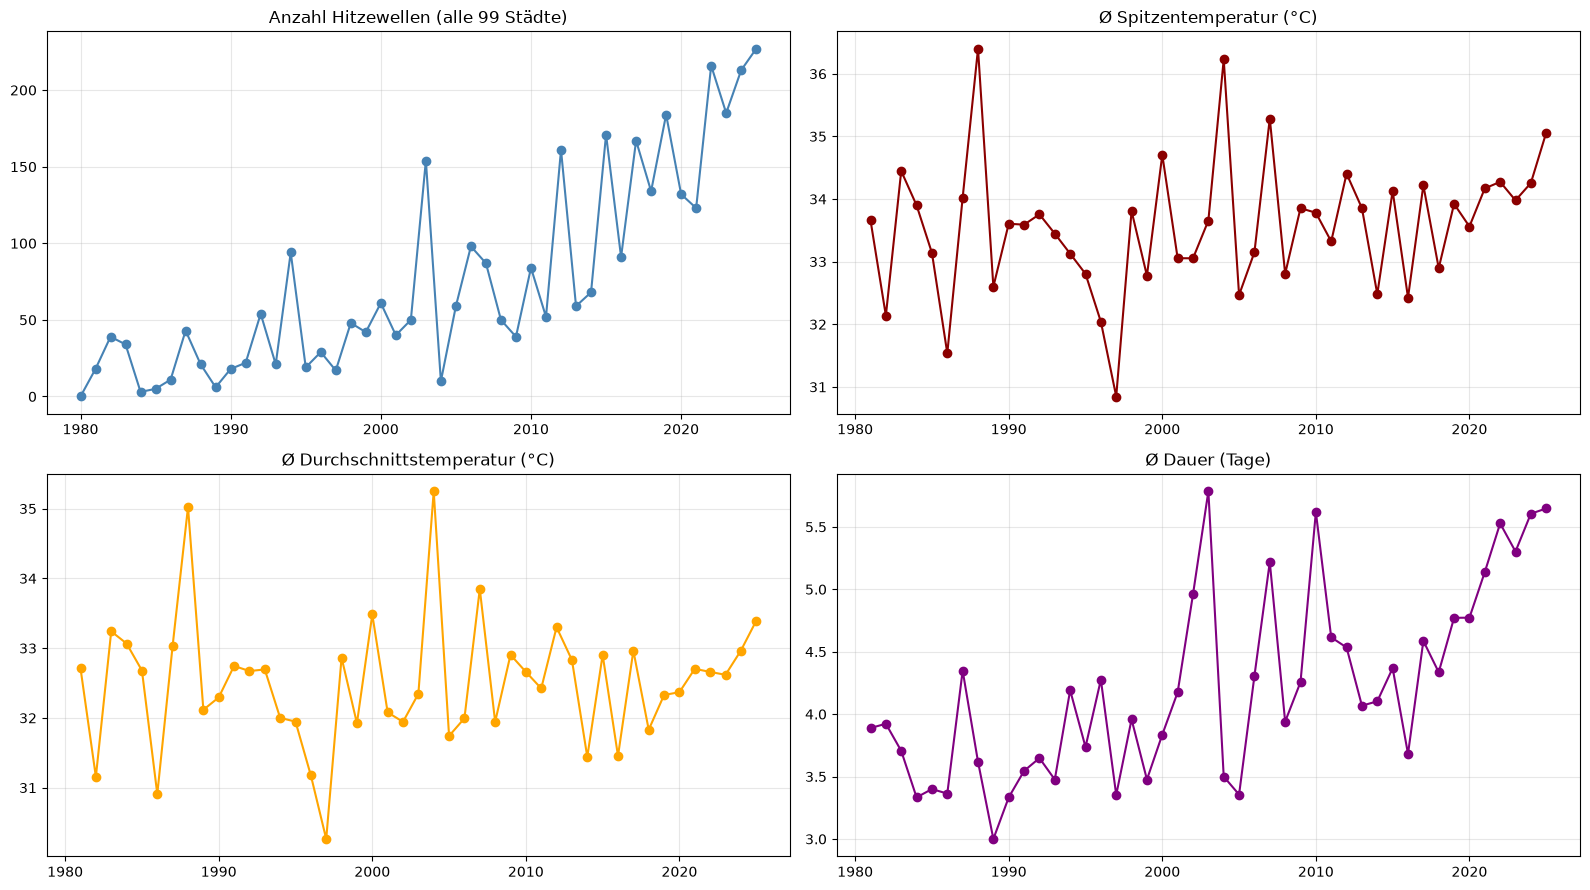

In [32]:
# Zelle 15
import matplotlib.pyplot as plt

n_cities = len(cities_df) - len(exclude_idx)

yearly = (pd.DataFrame({"year": range(1980, 2026)})
          .merge(results_df.groupby("year").agg(
              n_heatwaves=("city", "count"),
              avg_max_temp=("max_temp", "mean"),
              avg_avg_temp=("avg_temp", "mean"),
              avg_duration=("duration_days", "mean"),
          ).reset_index(), on="year", how="left"))
yearly["n_heatwaves"] = yearly["n_heatwaves"].fillna(0).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
plots = [("n_heatwaves", f"Anzahl Hitzewellen (alle {n_cities} Städte)", axes[0,0], "steelblue"),
         ("avg_max_temp", "Ø Spitzentemperatur (°C)", axes[0,1], "darkred"),
         ("avg_avg_temp", "Ø Durchschnittstemperatur (°C)", axes[1,0], "orange"),
         ("avg_duration", "Ø Dauer (Tage)", axes[1,1], "purple")]

for col, label, ax, color in plots:
    ax.plot(yearly["year"], yearly[col], marker="o", color=color)
    ax.set_title(label)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/trend_overview_europe.png", dpi=150)
plt.show()

Zelle 16 — Ist der Trend statistisch echt?

Lineare Regression über die Jahre, für jede Kennzahl. Zusätzlich einmal ohne die Jahre 1980–1990 gerechnet, da diese sich mit der Referenzperiode überlappen und den frühen Teil sonst künstlich unauffällig aussehen lassen könnten.

In [33]:
# Zelle 17
from scipy import stats

metrics = [("n_heatwaves", "Häufigkeit"), ("avg_max_temp", "Spitzentemp."),
           ("avg_avg_temp", "Durchschnittstemp."), ("avg_duration", "Dauer")]

for period_label, data in [("1980–2025", yearly), ("1991–2025", yearly[yearly["year"] >= 1991])]:
    print(f"-- {period_label} --")
    for col, label in metrics:
        valid = data.dropna(subset=[col])
        slope, _, r, p, _ = stats.linregress(valid["year"], valid[col])
        signif = "signifikant" if p < 0.05 else "nicht signifikant"
        print(f"  {label}: {slope:+.3f}/Jahr, p={p:.4f} ({signif})")

-- 1980–2025 --
  Häufigkeit: +3.995/Jahr, p=0.0000 (signifikant)
  Spitzentemp.: +0.016/Jahr, p=0.1854 (nicht signifikant)
  Durchschnittstemp.: +0.004/Jahr, p=0.6896 (nicht signifikant)
  Dauer: +0.039/Jahr, p=0.0000 (signifikant)
-- 1991–2025 --
  Häufigkeit: +5.015/Jahr, p=0.0000 (signifikant)
  Spitzentemp.: +0.032/Jahr, p=0.0566 (nicht signifikant)
  Durchschnittstemp.: +0.015/Jahr, p=0.3058 (nicht signifikant)
  Dauer: +0.046/Jahr, p=0.0000 (signifikant)


Zelle 18 — Welches Land ist am stärksten betroffen?

Für jede Stadt: Steigung der Hitzewellen-Häufigkeit pro Jahr. Pro Land dann der **Median** über alle seine Städte — nicht der Durchschnitt, damit weder die Anzahl Städte pro Land noch einzelne Ausreißer das Ergebnis verzerren. Länder mit weniger als 3 Städten werden ausgeschlossen, da ein Median dort kaum aussagekräftig wäre.

In [34]:
# Zelle 19
city_trend = []
for city, group in results_df.groupby("city"):
    yearly_city = group.groupby("year").size().reindex(range(1980, 2026), fill_value=0)
    slope, _, _, p, _ = stats.linregress(yearly_city.index, yearly_city.values)
    city_trend.append({"city": city, "country": group["country"].iloc[0], "slope": slope, "p_value": p})

city_trend_df = pd.DataFrame(city_trend)

country_trend = (city_trend_df.groupby("country")
                  .agg(median_slope=("slope", "median"), n_cities=("city", "count"))
                  .query("n_cities >= 3")
                  .sort_values("median_slope", ascending=False))

top3 = country_trend.head(3).index.tolist()
print(country_trend)
print(f"\nTop 3: {top3}")

                median_slope  n_cities
country                               
Italy               0.068239         6
Ukraine             0.065865         9
Spain               0.060870         6
Poland              0.044712         5
France              0.041505         4
Germany             0.037064        15
United Kingdom      0.004810         5

Top 3: ['Italy', 'Ukraine', 'Spain']


Zelle 20 — Zweiter Blick: Dauer und Temperatur

Dieselbe Methode, diesmal für Dauer und Temperatur statt Häufigkeit — als Gegenprobe, ob dasselbe Land auch bei diesen Faktoren vorne liegt. Städte mit weniger als 10 Jahren mit Hitzewellen werden übersprungen (zu wenige Datenpunkte für eine verlässliche Regression).

In [35]:
# Zelle 21
city_dt = []
for city, group in results_df.groupby("city"):
    yearly_city = group.groupby("year").agg(avg_duration=("duration_days", "mean"),
                                              avg_temp=("avg_temp", "mean")).reindex(range(1980, 2026))
    row = {"city": city, "country": group["country"].iloc[0]}
    for col, label in [("avg_duration", "duration_slope"), ("avg_temp", "temp_slope")]:
        valid = yearly_city.dropna(subset=[col])
        row[label] = stats.linregress(valid.index, valid[col])[0] if len(valid) >= 10 else np.nan
    city_dt.append(row)

country_dt = pd.DataFrame(city_dt).groupby("country").agg(
    duration_slope=("duration_slope", "median"), temp_slope=("temp_slope", "median"),
    n_cities_duration=("duration_slope", "count"), n_cities_temp=("temp_slope", "count"))

comparison = country_trend.join(country_dt)
print(comparison.sort_values("median_slope", ascending=False))

                median_slope  n_cities  duration_slope  temp_slope  \
country                                                              
Italy               0.068239         6        0.052048    0.015644   
Ukraine             0.065865         9       -0.007232    0.015019   
Spain               0.060870         6        0.019569    0.009840   
Poland              0.044712         5       -0.007060   -0.003568   
France              0.041505         4        0.022577    0.013112   
Germany             0.037064        15        0.020322    0.016241   
United Kingdom      0.004810         5        0.013524    0.035813   

                n_cities_duration  n_cities_temp  
country                                           
Italy                           6              6  
Ukraine                         9              9  
Spain                           6              6  
Poland                          5              5  
France                          4              4  
Germany     

Zelle 22 — Alle drei Faktoren im Vergleich

Häufigkeit, Dauer und Temperatur nebeneinander, gleiche Länder-Reihenfolge, Top-3-Länder farblich hervorgehoben. Schraffierte Balken beruhen auf weniger als 3 Städten (im Extremfall nur einer einzigen) und sind entsprechend vorsichtig zu lesen.

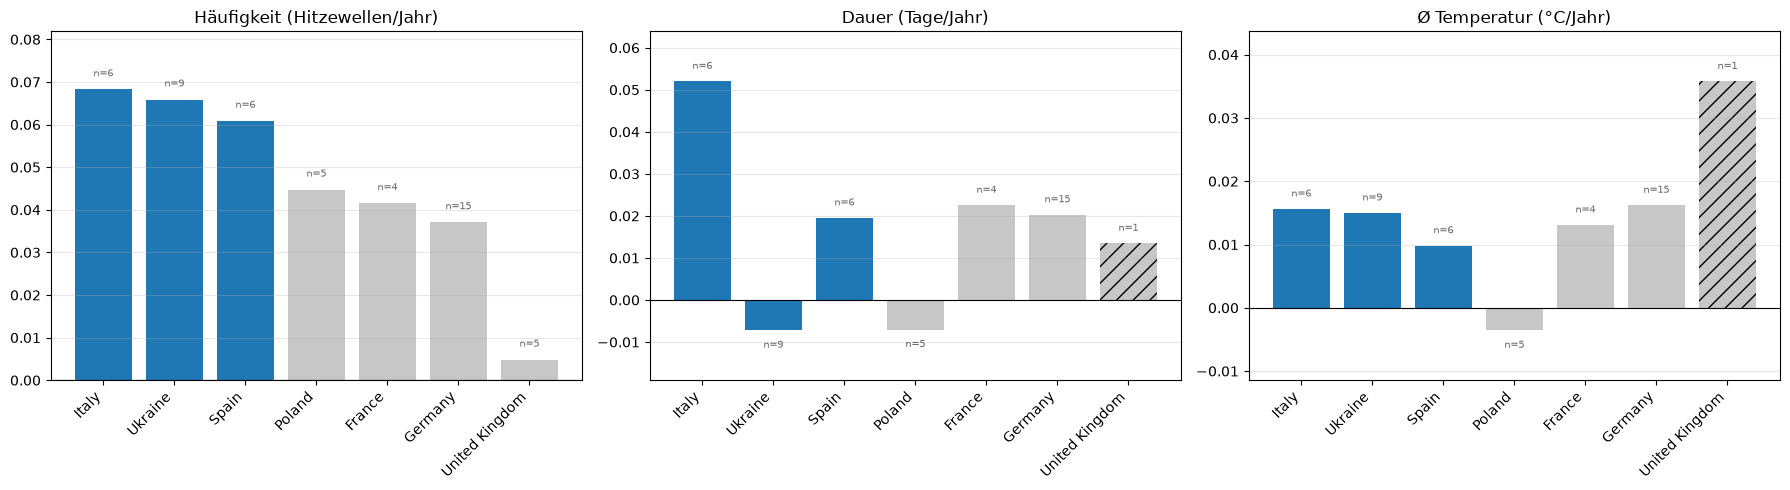

In [39]:
# Zelle 23
order = comparison.sort_values("median_slope", ascending=False).index.tolist()
factors = [("median_slope", "n_cities", "Häufigkeit (Hitzewellen/Jahr)"),
           ("duration_slope", "n_cities_duration", "Dauer (Tage/Jahr)"),
           ("temp_slope", "n_cities_temp", "Ø Temperatur (°C/Jahr)")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (val_col, n_col, title) in zip(axes, factors):
    values, n_counts = comparison.loc[order, val_col], comparison.loc[order, n_col]
    colors = ["#1f77b4" if c in top3 else "#c7c7c7" for c in order]
    bars = ax.bar(order, values, color=colors)

    # Etwas Platz über/unter den Balken freihalten, damit die n=-Labels nicht
    # am Plotrand abgeschnitten werden oder mit den Länder-Namen überlappen.
    ax.margins(y=0.2)
    # Offset relativ zur Spannweite DIESES Panels statt fixem Wert -- sonst passt
    # er nur für eine der drei unterschiedlichen Skalen.
    offset = (values.max() - values.min()) * 0.04

    for bar, n in zip(bars, n_counts):
        if n < 3:
            bar.set_hatch("//")
        is_positive = bar.get_height() >= 0
        va = "bottom" if is_positive else "top"
        y = bar.get_height() + offset if is_positive else bar.get_height() - offset
        ax.text(bar.get_x() + bar.get_width()/2, y, f"n={n}",
                 ha="center", va=va, fontsize=7, color="dimgray")

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=45, ha="right")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("data/processed/trend_by_factor_countries.png", dpi=150)
plt.show()

Zelle 24 — Zeitverlauf der Top-3-Länder

Tatsächlicher Jahresverlauf (Summe über alle Städte des jeweiligen Landes) plus lineare Trendlinie, für die drei am stärksten betroffenen Länder.

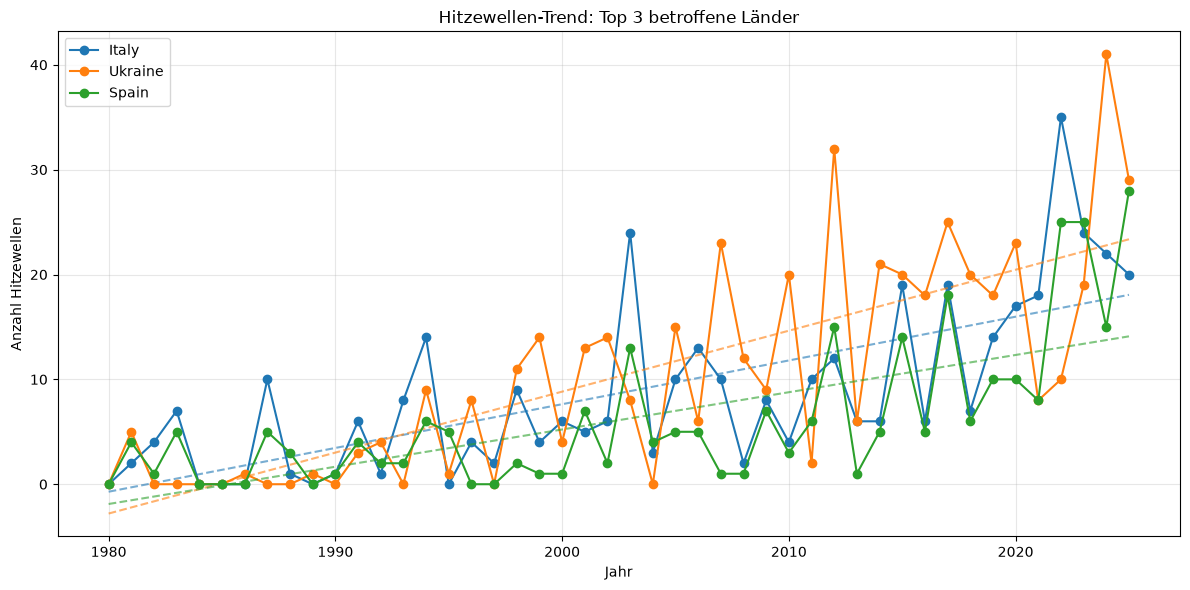

In [37]:
# Zelle 25
fig, ax = plt.subplots(figsize=(12, 6))
for country in top3:
    country_yearly = (pd.DataFrame({"year": range(1980, 2026)})
                       .merge(results_df[results_df["country"] == country]
                              .groupby("year").size().rename("n").reset_index(),
                              on="year", how="left").fillna({"n": 0}))
    line = ax.plot(country_yearly["year"], country_yearly["n"], marker="o", label=country)[0]
    slope, intercept, *_ = stats.linregress(country_yearly["year"], country_yearly["n"])
    ax.plot(country_yearly["year"], slope * country_yearly["year"] + intercept,
            linestyle="--", alpha=0.6, color=line.get_color())

ax.set_xlabel("Jahr")
ax.set_ylabel("Anzahl Hitzewellen")
ax.set_title("Hitzewellen-Trend: Top 3 betroffene Länder")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("data/processed/trend_top3_countries.png", dpi=150)
plt.show()

## Fazit

Europaweit sind Hitzewellen seit 1980 signifikant häufiger (+4,0/Jahr, p<0,001) und länger geworden (+0,04 Tage/Jahr, p<0,001) — die Temperatur innerhalb bereits erkannter Hitzewellen zeigt dagegen keinen signifikanten Trend. Hitzewellen werden also häufiger und dauern länger, ohne dass die einzelne Hitzewelle dabei spürbar heißer wird.

**Am stärksten betroffen ist Italien** — höchster Median-Trend bei der Häufigkeit (0,068 zusätzliche Hitzewellen pro Stadt und Jahr), mit deutlichem Abstand zu Platz 4 (Polen). Rom und Turin, die beiden größten italienischen Städte im Datensatz, zeigen dabei einzeln hochsignifikante Anstiege. Bei Dauer und Temperatur liegt Italien ebenfalls unter den Spitzenreitern, wenn auch nicht immer an erster Stelle — Ukraine und Spanien liegen bei der Häufigkeit nur knapp dahinter.

**Einschränkungen:**
- Die feste 28°C-Schwelle (DWD-Definition) benachteiligt strukturell kühlere Länder — sie können per Definition kaum Hitzewellen erreichen, unabhängig davon, wie ungewöhnlich warm ein Tag für ihre Verhältnisse war.
- Das Vereinigte Königreich beruht bei Dauer/Temperatur auf nur einer einzigen Stadt (schraffiert im Diagramm) und ist dort nicht robust vergleichbar.
- Die Auswahl der Städte (≥500.000 Einwohner oder Hauptstadt) sagt nichts darüber aus, ob sich der Effekt auf Großstädte konzentriert oder auch kleinere Orte gleichermaßen betrifft — dafür wäre eine eigene, größenschichtete Datenerhebung nötig.